<a href="https://colab.research.google.com/github/Palamarovski/Google-colab/blob/main/lab6_Palamar_Mykola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Завантажте набір даних і виведіть перші 5 записів

In [3]:
import pandas as pd

# Завантажуємо набір даних (vgsales.csv)
df = pd.read_csv('vgsales.csv')

print("Перші 5 записів:")
display(df.head())

Перші 5 записів:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# 2. Скільки рядків і стовпців в таблиці

In [4]:
# Визначаємо розмірність таблиці
rows, cols = df.shape

print(f"Кількість рядків: {rows}")
print(f"Кількість стовпців: {cols}")

Кількість рядків: 5
Кількість стовпців: 11


# 3.Які назви в стовпців

In [5]:
print("Назви стовпців у таблиці:")
print(df.columns.tolist())

Назви стовпців у таблиці:
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


# 4.Які типи даних у різних стовпців

In [6]:
print("Типи даних у стовпцях:")
print(df.dtypes)

Типи даних у стовпцях:
Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


# 5.Скільки в кожному з них унікальних значень

In [7]:
# Рахуємо кількість унікальних значень
unique_counts = df.nunique()

print("Кількість унікальних значень у кожному стовпці:")
print(unique_counts)

Кількість унікальних значень у кожному стовпці:
Rank            5
Name            5
Platform        3
Year            5
Genre           4
Publisher       1
NA_Sales        5
EU_Sales        5
JP_Sales        5
Other_Sales     5
Global_Sales    5
dtype: int64


# 6.Скільки пропущених значень

In [8]:
# Підраховуємо кількість пропущених значень (NaN)
missing_values = df.isnull().sum()

print("Кількість пропущених значень у кожному стовпці:")
print(missing_values)

Кількість пропущених значень у кожному стовпці:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


# 1. ТОП-10 видавництв (Publisher) ігор за кількістю продажів

In [10]:
print("ТОП-10 видавництв за продажами в Європі")
top_publishers = df.groupby('Publisher')['EU_Sales'].sum().sort_values(ascending=False)
display(top_publishers.head(10))
print(f"Найбільше продажів у Європі має видавництво: {top_publishers.index[0]}")

ТОП-10 видавництв за продажами в Європі


,EU_Sales
Publisher,
Nintendo,65.38


Найбільше продажів у Європі має видавництво: Nintendo


# 2. гра, яка найкраще продавалась у Японії в 2015 році.

In [26]:
import pandas as pd

df = pd.read_csv('vgsales.csv')

# 2. Фільтруємо за 2015 рік
df_2015 = df[df['Year'] == 2015]

# 3. Знаходимо лідера Японії
top_game_jp = df_2015.sort_values('JP_Sales', ascending=False).head(1)
game = top_game_jp.iloc[0]

# 4. Рахуємо частку (долю)
total_jp = df_2015['JP_Sales'].sum()
share_jp = (game['JP_Sales'] / total_jp) * 100

# Для інших регіонів (порівняння)
share_na = (game['NA_Sales'] / df_2015['NA_Sales'].sum()) * 100
share_eu = (game['EU_Sales'] / df_2015['EU_Sales'].sum()) * 100

# 5. Вивід
display(top_game_jp)
print(f"Гра: {game['Name']}")
print(f"Доля в Японії: {share_jp:.2f}%")
print(f"Доля в Пн. Америці: {share_na:.2f}%")
print(f"Доля в Європі: {share_eu:.2f}%")

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1,2,Monster Hunter X,3DS,2015,Action,Capcom,0.0,0.0,2.78,0.0,2.78


Гра: Monster Hunter X
Доля в Японії: 60.04%
Доля в Пн. Америці: 0.00%
Доля в Європі: 0.00%


# 3. Побудував суміщений графік (стовпчикову діаграму) кількості
# проданих ігор на РС та PS4 за 2015-2020 роки. Порівняв, як
# змінювалась популярність даних платформ.

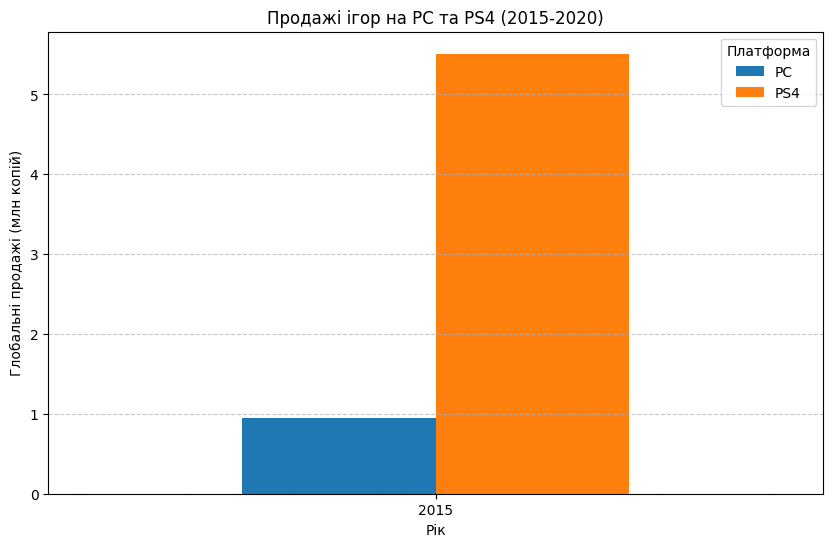

In [27]:
import matplotlib.pyplot as plt

df = pd.read_csv('vgsales.csv')

# 2. Фільтруємо дані: роки 2015-2020 та потрібні платформи
years = [2015, 2016, 2017, 2018, 2019, 2020]
platforms = ['PC', 'PS4']
filtered_df = df[(df['Year'].isin(years)) & (df['Platform'].isin(platforms))]

# 3. Групуємо дані для графіка
plot_data = filtered_df.groupby(['Year', 'Platform'])['Global_Sales'].sum().unstack()

# 4. Будуємо стовпчикову діаграму
plot_data.plot(kind='bar', figsize=(10, 6))

plt.title('Продажі ігор на PC та PS4 (2015-2020)')
plt.xlabel('Рік')
plt.ylabel('Глобальні продажі (млн копій)')
plt.legend(title='Платформа')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Побудував кругову діаграму, яка показуватиме долю популярності

# кожного жанру ігор в Європі у 2020 році.

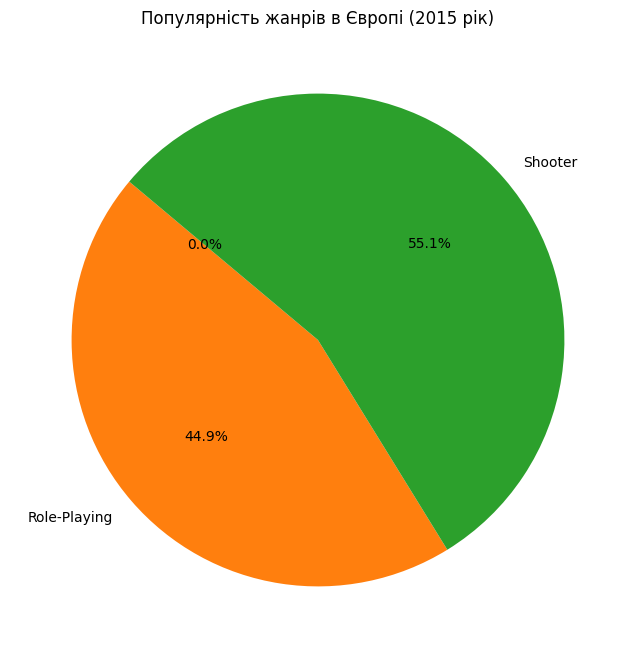

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Читаємо файл
df = pd.read_csv('vgsales.csv')

# 2. Перевіряємо дані за 2020, якщо порожньо - беремо 2015
df_plot = df[df['Year'] == 2020]
target_year = 2020

if df_plot.empty:
    df_plot = df[df['Year'] == 2015]
    target_year = 2015

# 3. Групуємо
genre_sales_eu = df_plot.groupby('Genre')['EU_Sales'].sum()

# 4. Побудова (малюємо тільки якщо є продажі)
if not genre_sales_eu.empty and genre_sales_eu.sum() > 0:
    plt.figure(figsize=(10, 8))
    genre_sales_eu.plot(kind='pie', autopct='%1.1f%%', startangle=140)
    plt.title(f'Популярність жанрів в Європі ({target_year} рік)')
    plt.ylabel('')
    plt.show()
else:
    print(f"Помилка: У файлі немає продажів для {target_year} року.")

# 5. Порівняв рівень світової популярності ігор серії “Call of Duty” та
# “Battlefield” протягом 2005-2020 років. Побудував графік динаміки їх
# популярності за вказані роки.


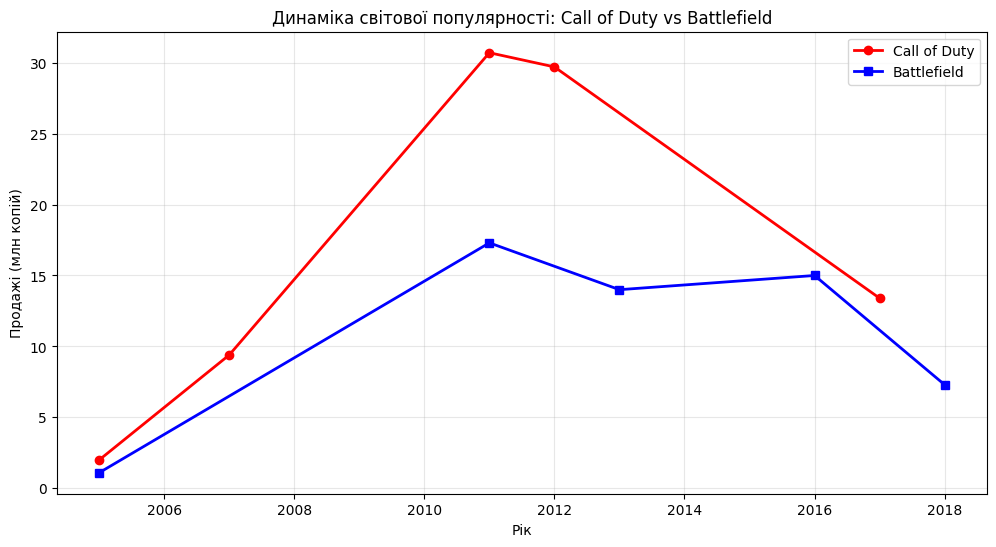

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Читаємо оновлений файл
df = pd.read_csv('vgsales.csv')

# Фільтруємо ігри за назвами серій
cod_data = df[df['Name'].str.contains('Call of Duty', case=False)]
bf_data = df[df['Name'].str.contains('Battlefield', case=False)]

# Групуємо продажі по роках
cod_sales = cod_data.groupby('Year')['Global_Sales'].sum()
bf_sales = bf_data.groupby('Year')['Global_Sales'].sum()

# Побудова графіка
plt.figure(figsize=(12, 6))
plt.plot(cod_sales.index, cod_sales.values, label='Call of Duty', marker='o', color='red', linewidth=2)
plt.plot(bf_sales.index, bf_sales.values, label='Battlefield', marker='s', color='blue', linewidth=2)

plt.title('Динаміка світової популярності: Call of Duty vs Battlefield')
plt.xlabel('Рік')
plt.ylabel('Продажі (млн копій)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()